**About DIGITS Dataset**:  This dataset is the collection of handwritten numerical digits commonly used for image classification and machine learning experiments. The most well-known variant is the MNIST dataset, which consists of 60,000 training images and 10,000 test images of grayscale handwritten digits (0-9) with a resolution of 28x28 pixels. Each image represents a single-digit number, and the dataset is widely used as a benchmark for evaluating machine learning models, particularly in deep learning and convolutional neural networks (CNNs). The dataset is essential in the field of computer vision and serves as an introductory problem for classification tasks due to its simplicity, large size, and well-labelled format.
First of all, we need to import the essential libraries. Essential libraries:
TensorFlow and Keras for building and training CNN models while NumPy for handling numerical computations and Matplotlib will visualize the results.

Please make sure you have installed these libraries or use Google Collab to avoid issues.



In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

Here, we load the MNIST dataset and normalize pixel values between 0 and 1 to speed up training and improve convergence.

In [2]:
# Choose dataset (Uncomment for CIFAR-10)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize data
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Reshape dataset to match model's expected input shape (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0


Next, as we imported the essential libraries and then downloaded the dataset, lets design/define the architecture of the CNN model.


First Convolutional Layer:
Conv2D (32, (3,3), activation='relu'): This layer extracts 32 different patterns from the input using 3x3 filters. The ReLU activation introduces non-linearity, making it easier to learn complex patterns.
MaxPooling2D ((2,2)): Downsamples the feature maps by selecting the most important features, reducing computation and preventing overfitting.

Second Convolutional Layer:
Conv2D(64, (3,3), activation='relu'): Uses 64 filters to extract more refined patterns from previous feature maps.
MaxPooling2D((2,2)): Further reduces dimensionality while keeping key features.

Flatten Layer:
Flatten(): Converts 2D feature maps into a 1D vector, making it compatible with dense layers.

Fully Connected Layers:
Dense(64, activation='relu'): A hidden layer with 64 neurons to learn high-level representations.
Dense(10, activation='softmax'): Output layer with 10 neurons (one per digit), using softmax activation for probability distribution.

Followed by the compilation of the model, where

Adam Optimizer: An adaptive learning rate method that helps achieve faster convergence.
Sparse Categorical Crossentropy: A loss function used for multi-class classification with integer labels.
Accuracy Metric: Measures how often the model correctly classifies the digits.

In [4]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    # layers.Dropout(0.5),   # Drop 50% of neurons #Each forward pass uses a different sub-network. Reduces overfitting by forcing neurons to be independent.
    layers.Dense(10, activation='softmax')
])

# from tensorflow.keras import regularizers
#L2 forces weights to stay small. Training accuracy might drop a little, but test accuracy should improve.


# model_l2 = keras.Sequential([
#     layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1),
#                   kernel_regularizer=regularizers.l2(0.001)),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64, (3,3), activation='relu',
#                   kernel_regularizer=regularizers.l2(0.001)),
#     layers.MaxPooling2D((2,2)),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu',
#                  kernel_regularizer=regularizers.l2(0.001)),
#     layers.Dense(10, activation='softmax')
# ])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Let’s start training. We train the CNN for 5 epochs, meaning the model sees the entire dataset 5 times. The validation data helps monitor performance and detect overfitting.

In [ ]:
# early_stop = keras.callbacks.EarlyStopping(
#     monitor='val_loss', patience=3, restore_best_weights=True)

# history = model_dropout.fit(x_train, y_train,
#                             validation_data=(x_test, y_test),
#                             epochs=30,
#                             batch_size=64,
#                             callbacks=[early_stop])


In [5]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.8994 - loss: 0.3194 - val_accuracy: 0.9851 - val_loss: 0.0448
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9846 - loss: 0.0498 - val_accuracy: 0.9861 - val_loss: 0.0423
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9910 - loss: 0.0315 - val_accuracy: 0.9873 - val_loss: 0.0368
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9895 - val_loss: 0.0320
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9943 - loss: 0.0177 - val_accuracy: 0.9856 - val_loss: 0.0490


We visualize the training and validation accuracy across epochs. A large gap between them could indicate overfitting. Although, the graph/curve will not be too smooth as there are only 5 epochs applied to train the model.

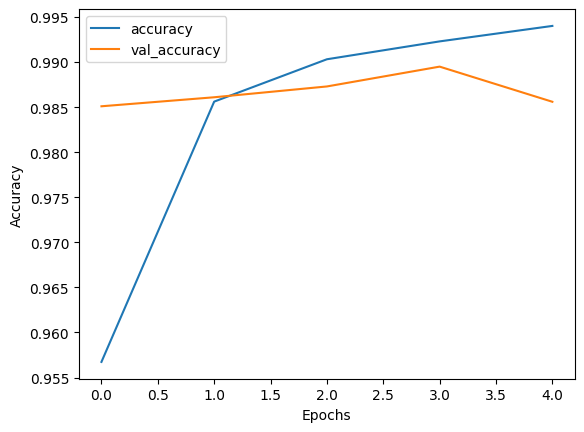

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

If you want to see which images/digits are wrongly classified, you can run the following snippet.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


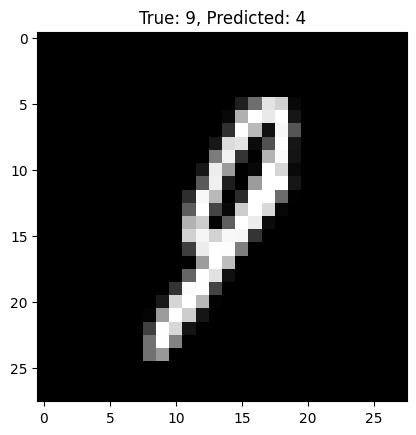

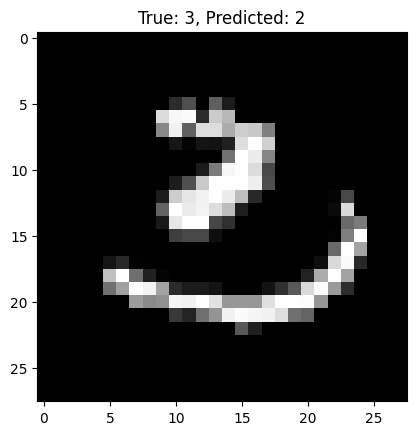

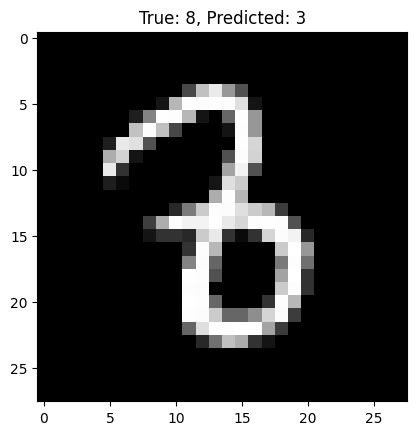

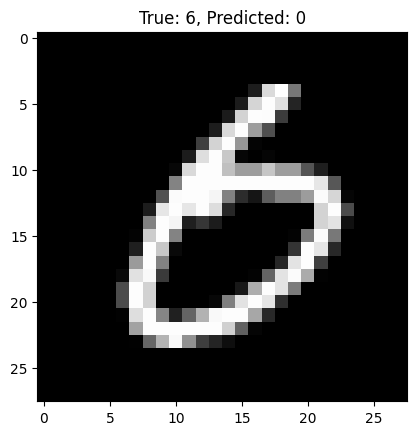

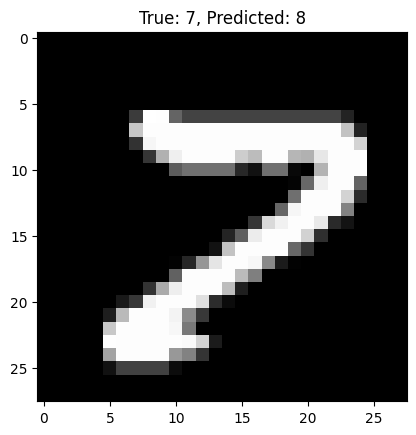

In [7]:
import random
predictions = model.predict(x_test)
misclassified_indices = [i for i in range(len(y_test)) if np.argmax(predictions[i]) != y_test[i]]
random_samples = random.sample(misclassified_indices, 5)

for i in random_samples:
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]}, Predicted: {np.argmax(predictions[i])}")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


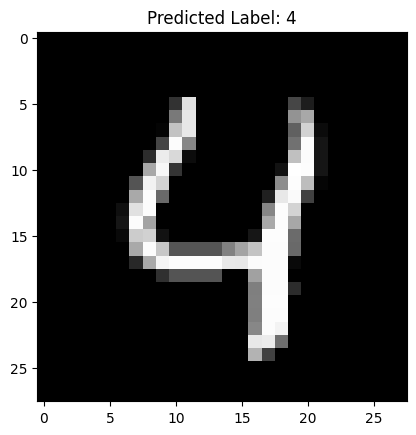

In [10]:
import cv2

# Load a single test image (from test dataset)
index = 4  # Change this index to test different images
single_image = x_test[index]

# Preprocess the image (reshape and normalize)
single_image = single_image.reshape(1, 28, 28, 1)

# Make a prediction
prediction = model.predict(single_image)
predicted_label = np.argmax(prediction)

# Display the image and the predicted label
plt.imshow(x_test[index], cmap='gray')
plt.title(f"Predicted Label: {predicted_label}")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


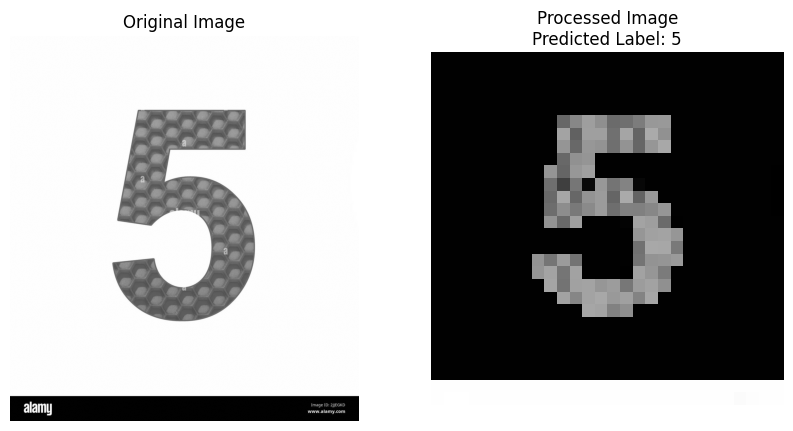

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the image from file
image_path = "/content/drive/My Drive/5.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not loaded. Check file path.")
else:
    # Display the original and processed images
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # Resize image to match MNIST dimensions
    image_resized = cv2.resize(image, (28, 28))

    # Invert colors if needed (MNIST is white digits on black background)
    image_resized = 255 - image_resized

    # Normalize and reshape the image
    image_resized = image_resized.astype("float32") / 255.0
    image_resized = image_resized.reshape(1, 28, 28, 1)  # Ensure correct input shape

    prediction = model.predict(image_resized)
    predicted_label = np.argmax(prediction)

    # Processed Image
    plt.subplot(1, 2, 2)
    plt.imshow(image_resized.reshape(28, 28), cmap='gray')
    plt.title(f"Processed Image\nPredicted Label: {predicted_label}")
    plt.axis('off')
    plt.show()